<a href="https://colab.research.google.com/github/natalyassis-lgtm/sistema-rotas-acessiveis-ufma-a-star/blob/main/Projeto_IA_Solar_Flare_Regress%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/solar-flare/flare.data2"

colunas = [
    "classe_zurich_modificada",
    "tamanho_maior_mancha",
    "distribuicao_manchas",
    "atividade",
    "evolucao",
    "atividade_flares_24h_anteriores",
    "historicamente_complexa",
    "ficou_complexa_nesta_passagem",
    "area",
    "area_maior_mancha",
    "flares_C_24h",
    "flares_M_24h",
    "flares_X_24h"
]

df = pd.read_csv(
    url,
    sep=r"\s+",
    header=None,
    names=colunas,
    skiprows=1
)

df.head()

,classe_zurich_modificada,tamanho_maior_mancha,distribuicao_manchas,atividade,evolucao,atividade_flares_24h_anteriores,historicamente_complexa,ficou_complexa_nesta_passagem,area,area_maior_mancha,flares_C_24h,flares_M_24h,flares_X_24h
0,H,A,X,1,3,1,1,1,1,1,0,0,0
1,D,R,O,1,3,1,1,2,1,1,0,0,0
2,C,S,O,1,3,1,1,2,1,1,0,0,0
3,H,R,X,1,2,1,1,1,1,1,0,0,0
4,H,S,X,1,1,1,1,2,1,1,0,0,0


In [ ]:
df.shape

(1066, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1066 entries, 0 to 1065
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   classe_zurich_modificada         1066 non-null   object
 1   tamanho_maior_mancha             1066 non-null   object
 2   distribuicao_manchas             1066 non-null   object
 3   atividade                        1066 non-null   int64 
 4   evolucao                         1066 non-null   int64 
 5   atividade_flares_24h_anteriores  1066 non-null   int64 
 6   historicamente_complexa          1066 non-null   int64 
 7   ficou_complexa_nesta_passagem    1066 non-null   int64 
 8   area                             1066 non-null   int64 
 9   area_maior_mancha                1066 non-null   int64 
 10  flares_C_24h                     1066 non-null   int64 
 11  flares_M_24h                     1066 non-null   int64 
 12  flares_X_24h                     1

In [ ]:
df.isnull().sum()

,0
classe_zurich_modificada,0
tamanho_maior_mancha,0
distribuicao_manchas,0
atividade,0
evolucao,0
atividade_flares_24h_anteriores,0
historicamente_complexa,0
ficou_complexa_nesta_passagem,0
area,0
area_maior_mancha,0


In [ ]:
df.describe()

,atividade,evolucao,atividade_flares_24h_anteriores,historicamente_complexa,ficou_complexa_nesta_passagem,area,area_maior_mancha,flares_C_24h,flares_M_24h,flares_X_24h
count,1066.000000,1066.000000,1066.000000,1066.000000,1066.000000,1066.000000,1066.0,1066.000000,1066.000000,1066.000000
mean,1.153846,2.401501,1.059099,1.404315,1.875235,1.025328,1.0,0.300188,0.046904,0.005629
std,0.360971,0.620584,0.320324,0.490989,0.330608,0.157194,0.0,0.835784,0.302811,0.086487
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,0.000000,0.000000,0.000000
25%,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.0,0.000000,0.000000,0.000000
50%,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.0,0.000000,0.000000,0.000000
75%,1.000000,3.000000,1.000000,2.000000,2.000000,1.000000,1.0,0.000000,0.000000,0.000000
max,2.000000,3.000000,3.000000,2.000000,2.000000,2.000000,1.0,8.000000,5.000000,2.000000


In [ ]:
X = df[
    [
        "classe_zurich_modificada",
        "tamanho_maior_mancha",
        "distribuicao_manchas",
        "atividade",
        "evolucao",
        "atividade_flares_24h_anteriores",
        "historicamente_complexa",
        "ficou_complexa_nesta_passagem",
        "area",
        "area_maior_mancha"
    ]
]

y = df[
    [
        "flares_C_24h",
        "flares_M_24h",
        "flares_X_24h"
    ]
]

In [ ]:
X.head()

,classe_zurich_modificada,tamanho_maior_mancha,distribuicao_manchas,atividade,evolucao,atividade_flares_24h_anteriores,historicamente_complexa,ficou_complexa_nesta_passagem,area,area_maior_mancha
0,H,A,X,1,3,1,1,1,1,1
1,D,R,O,1,3,1,1,2,1,1
2,C,S,O,1,3,1,1,2,1,1
3,H,R,X,1,2,1,1,1,1,1
4,H,S,X,1,1,1,1,2,1,1


In [ ]:
y.head()

,flares_C_24h,flares_M_24h,flares_X_24h
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0


In [ ]:
print("Tamanho de X:", X.shape)
print("Tamanho de y:", y.shape)

Tamanho de X: (1066, 10)
Tamanho de y: (1066, 3)


In [ ]:
y.describe()

,flares_C_24h,flares_M_24h,flares_X_24h
count,1066.000000,1066.000000,1066.000000
mean,0.300188,0.046904,0.005629
std,0.835784,0.302811,0.086487
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000
max,8.000000,5.000000,2.000000


In [ ]:
y.sum()

,0
flares_C_24h,320
flares_M_24h,50
flares_X_24h,6


In [ ]:
for coluna in y.columns:
    print(f"\nDistribuição de {coluna}:")
    print(y[coluna].value_counts().sort_index())


Distribuição de flares_C_24h:
flares_C_24h
0    884
1    112
2     33
3     20
4      9
5      4
6      3
8      1
Name: count, dtype: int64

Distribuição de flares_M_24h:
flares_M_24h
0    1030
1      29
2       3
3       2
4       1
5       1
Name: count, dtype: int64

Distribuição de flares_X_24h:
flares_X_24h
0    1061
1       4
2       1
Name: count, dtype: int64


In [ ]:
df.dtypes

,0
classe_zurich_modificada,object
tamanho_maior_mancha,object
distribuicao_manchas,object
atividade,int64
evolucao,int64
atividade_flares_24h_anteriores,int64
historicamente_complexa,int64
ficou_complexa_nesta_passagem,int64
area,int64
area_maior_mancha,int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1066 entries, 0 to 1065
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   classe_zurich_modificada         1066 non-null   object
 1   tamanho_maior_mancha             1066 non-null   object
 2   distribuicao_manchas             1066 non-null   object
 3   atividade                        1066 non-null   int64 
 4   evolucao                         1066 non-null   int64 
 5   atividade_flares_24h_anteriores  1066 non-null   int64 
 6   historicamente_complexa          1066 non-null   int64 
 7   ficou_complexa_nesta_passagem    1066 non-null   int64 
 8   area                             1066 non-null   int64 
 9   area_maior_mancha                1066 non-null   int64 
 10  flares_C_24h                     1066 non-null   int64 
 11  flares_M_24h                     1066 non-null   int64 
 12  flares_X_24h                     1

In [ ]:
df.isnull().sum()

,0
classe_zurich_modificada,0
tamanho_maior_mancha,0
distribuicao_manchas,0
atividade,0
evolucao,0
atividade_flares_24h_anteriores,0
historicamente_complexa,0
ficou_complexa_nesta_passagem,0
area,0
area_maior_mancha,0


In [ ]:
df.duplicated().sum()

np.int64(701)

In [ ]:
duplicadas = df[df.duplicated()]
duplicadas.head()

,classe_zurich_modificada,tamanho_maior_mancha,distribuicao_manchas,atividade,evolucao,atividade_flares_24h_anteriores,historicamente_complexa,ficou_complexa_nesta_passagem,area,area_maior_mancha,flares_C_24h,flares_M_24h,flares_X_24h
9,B,X,O,1,3,1,1,2,1,1,0,0,0
10,C,A,O,1,2,1,1,2,1,1,0,0,0
11,B,X,O,1,3,1,1,2,1,1,0,0,0
14,B,X,O,1,3,1,1,2,1,1,0,0,0
18,B,X,O,1,2,1,1,2,1,1,0,0,0


In [ ]:
percentual_duplicadas = df.duplicated().sum() / len(df) * 100

print("Quantidade de duplicatas:", df.duplicated().sum())
print("Percentual de duplicatas:", round(percentual_duplicadas, 2), "%")

Quantidade de duplicatas: 701
Percentual de duplicatas: 65.76 %


In [ ]:
df_limpo = df.drop_duplicates().reset_index(drop=True)

df_limpo.shape

(365, 13)

In [ ]:
X = df_limpo[
    [
        "classe_zurich_modificada",
        "tamanho_maior_mancha",
        "distribuicao_manchas",
        "atividade",
        "evolucao",
        "atividade_flares_24h_anteriores",
        "historicamente_complexa",
        "ficou_complexa_nesta_passagem",
        "area",
        "area_maior_mancha"
    ]
]

y = df_limpo[
    [
        "flares_C_24h",
        "flares_M_24h",
        "flares_X_24h"
    ]
]

In [ ]:
print("Tamanho de X:", X.shape)
print("Tamanho de y:", y.shape)

Tamanho de X: (365, 10)
Tamanho de y: (365, 3)


In [ ]:
X.nunique()

,0
classe_zurich_modificada,6
tamanho_maior_mancha,6
distribuicao_manchas,4
atividade,2
evolucao,3
atividade_flares_24h_anteriores,3
historicamente_complexa,2
ficou_complexa_nesta_passagem,2
area,2
area_maior_mancha,1


In [ ]:
X = X.drop(columns=["area_maior_mancha"])

X.nunique()

,0
classe_zurich_modificada,6
tamanho_maior_mancha,6
distribuicao_manchas,4
atividade,2
evolucao,3
atividade_flares_24h_anteriores,3
historicamente_complexa,2
ficou_complexa_nesta_passagem,2
area,2


In [ ]:
X.shape

(365, 9)

In [ ]:
y.describe()

,flares_C_24h,flares_M_24h,flares_X_24h
count,365.000000,365.000000,365.000000
mean,0.775342,0.131507,0.016438
std,1.257481,0.501886,0.147333
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,1.000000,0.000000,0.000000
max,8.000000,5.000000,2.000000


In [ ]:
y.sum()

,0
flares_C_24h,283
flares_M_24h,48
flares_X_24h,6


In [ ]:
analise_zeros = pd.DataFrame({
    "quantidade_zero": (y == 0).sum(),
    "quantidade_nao_zero": (y != 0).sum(),
    "percentual_zero": ((y == 0).sum() / len(y) * 100).round(2),
    "percentual_nao_zero": ((y != 0).sum() / len(y) * 100).round(2)
})

analise_zeros

,quantidade_zero,quantidade_nao_zero,percentual_zero,percentual_nao_zero
flares_C_24h,217,148,59.45,40.55
flares_M_24h,331,34,90.68,9.32
flares_X_24h,360,5,98.63,1.37


In [ ]:
for coluna in y.columns:
    print(f"\nDistribuição de {coluna}:")
    print(y[coluna].value_counts().sort_index())


Distribuição de flares_C_24h:
flares_C_24h
0    217
1     80
2     32
3     19
4      9
5      4
6      3
8      1
Name: count, dtype: int64

Distribuição de flares_M_24h:
flares_M_24h
0    331
1     27
2      3
3      2
4      1
5      1
Name: count, dtype: int64

Distribuição de flares_X_24h:
flares_X_24h
0    360
1      4
2      1
Name: count, dtype: int64


In [ ]:
df_limpo["total_flares_24h"] = (
    df_limpo["flares_C_24h"] +
    df_limpo["flares_M_24h"] +
    df_limpo["flares_X_24h"]
)

df_limpo["total_flares_24h"].describe()

,total_flares_24h
count,365.000000
mean,0.923288
std,1.417950
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,8.000000


In [ ]:
df_limpo["total_flares_24h"].value_counts().sort_index()

,count
total_flares_24h,
0,200
1,85
2,35
3,22
4,11
5,4
6,6
8,2


In [ ]:
df_limpo["teve_algum_flare"] = df_limpo["total_flares_24h"] > 0

df_limpo["teve_algum_flare"].value_counts()

,count
teve_algum_flare,
False,200
True,165


In [ ]:
df_limpo["teve_algum_flare"].value_counts(normalize=True) * 100

,proportion
teve_algum_flare,
False,54.794521
True,45.205479


In [ ]:
y.describe()

,flares_C_24h,flares_M_24h,flares_X_24h
count,365.000000,365.000000,365.000000
mean,0.775342,0.131507,0.016438
std,1.257481,0.501886,0.147333
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,1.000000,0.000000,0.000000
max,8.000000,5.000000,2.000000


In [ ]:
y.sum()

,0
flares_C_24h,283
flares_M_24h,48
flares_X_24h,6


In [ ]:
analise_zeros

,quantidade_zero,quantidade_nao_zero,percentual_zero,percentual_nao_zero
flares_C_24h,217,148,59.45,40.55
flares_M_24h,331,34,90.68,9.32
flares_X_24h,360,5,98.63,1.37


In [ ]:
df_limpo["total_flares_24h"].value_counts().sort_index()

,count
total_flares_24h,
0,200
1,85
2,35
3,22
4,11
5,4
6,6
8,2


In [ ]:
df_limpo["teve_algum_flare"].value_counts(normalize=True) * 100

,proportion
teve_algum_flare,
False,54.794521
True,45.205479


In [ ]:
X = X.drop(columns=["area_maior_mancha"], errors="ignore")

X.nunique()

,0
classe_zurich_modificada,6
tamanho_maior_mancha,6
distribuicao_manchas,4
atividade,2
evolucao,3
atividade_flares_24h_anteriores,3
historicamente_complexa,2
ficou_complexa_nesta_passagem,2
area,2


In [ ]:
X.shape

(365, 9)

In [ ]:
y.describe()

,flares_C_24h,flares_M_24h,flares_X_24h
count,365.000000,365.000000,365.000000
mean,0.775342,0.131507,0.016438
std,1.257481,0.501886,0.147333
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,1.000000,0.000000,0.000000
max,8.000000,5.000000,2.000000


In [ ]:
y.sum()

,0
flares_C_24h,283
flares_M_24h,48
flares_X_24h,6


In [ ]:
analise_zeros = pd.DataFrame({
    "quantidade_zero": (y == 0).sum(),
    "quantidade_nao_zero": (y != 0).sum(),
    "percentual_zero": ((y == 0).sum() / len(y) * 100).round(2),
    "percentual_nao_zero": ((y != 0).sum() / len(y) * 100).round(2)
})

analise_zeros

,quantidade_zero,quantidade_nao_zero,percentual_zero,percentual_nao_zero
flares_C_24h,217,148,59.45,40.55
flares_M_24h,331,34,90.68,9.32
flares_X_24h,360,5,98.63,1.37


In [ ]:
df_limpo["total_flares_24h"] = (
    df_limpo["flares_C_24h"] +
    df_limpo["flares_M_24h"] +
    df_limpo["flares_X_24h"]
)

df_limpo["total_flares_24h"].value_counts().sort_index()

,count
total_flares_24h,
0,200
1,85
2,35
3,22
4,11
5,4
6,6
8,2


In [ ]:
df_limpo["teve_algum_flare"] = df_limpo["total_flares_24h"] > 0

df_limpo["teve_algum_flare"].value_counts()

,count
teve_algum_flare,
False,200
True,165


In [ ]:
df_limpo["teve_algum_flare"].value_counts(normalize=True) * 100

,proportion
teve_algum_flare,
False,54.794521
True,45.205479


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=df_limpo["teve_algum_flare"]
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (292, 9)
X_test: (73, 9)
y_train: (292, 3)
y_test: (73, 3)


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

colunas_entrada = X.columns.tolist()

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessador = ColumnTransformer(
    transformers=[
        ("onehot", onehot, colunas_entrada)
    ]
)

In [ ]:
X_train_processado = preprocessador.fit_transform(X_train)
X_test_processado = preprocessador.transform(X_test)

print("X_train original:", X_train.shape)
print("X_train processado:", X_train_processado.shape)

print("X_test original:", X_test.shape)
print("X_test processado:", X_test_processado.shape)

X_train original: (292, 9)
X_train processado: (292, 30)
X_test original: (73, 9)
X_test processado: (73, 30)


In [ ]:
nomes_novas_colunas = preprocessador.named_transformers_["onehot"].get_feature_names_out(colunas_entrada)

X_train_processado_df = pd.DataFrame(
    X_train_processado,
    columns=nomes_novas_colunas
)

X_train_processado_df.head()

,classe_zurich_modificada_B,classe_zurich_modificada_C,classe_zurich_modificada_D,classe_zurich_modificada_E,classe_zurich_modificada_F,classe_zurich_modificada_H,tamanho_maior_mancha_A,tamanho_maior_mancha_H,tamanho_maior_mancha_K,tamanho_maior_mancha_R,...,evolucao_3,atividade_flares_24h_anteriores_1,atividade_flares_24h_anteriores_2,atividade_flares_24h_anteriores_3,historicamente_complexa_1,historicamente_complexa_2,ficou_complexa_nesta_passagem_1,ficou_complexa_nesta_passagem_2,area_1,area_2
0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0


In [ ]:
analise_zeros

,quantidade_zero,quantidade_nao_zero,percentual_zero,percentual_nao_zero
flares_C_24h,217,148,59.45,40.55
flares_M_24h,331,34,90.68,9.32
flares_X_24h,360,5,98.63,1.37


In [ ]:
df_limpo["total_flares_24h"].value_counts().sort_index()

,count
total_flares_24h,
0,200
1,85
2,35
3,22
4,11
5,4
6,6
8,2


In [ ]:
df_limpo["teve_algum_flare"].value_counts(normalize=True) * 100

,proportion
teve_algum_flare,
False,54.794521
True,45.205479


In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (292, 9)
X_test: (73, 9)
y_train: (292, 3)
y_test: (73, 3)


In [ ]:
print("X_train processado:", X_train_processado.shape)
print("X_test processado:", X_test_processado.shape)

X_train processado: (292, 30)
X_test processado: (73, 30)


In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

In [ ]:
def avaliar_regressao(y_true, y_pred, nome_modelo):
    resultados = []

    for i, coluna in enumerate(y_true.columns):
        mae = mean_absolute_error(y_true[coluna], y_pred[:, i])
        rmse = np.sqrt(mean_squared_error(y_true[coluna], y_pred[:, i]))
        r2 = r2_score(y_true[coluna], y_pred[:, i])

        resultados.append({
            "modelo": nome_modelo,
            "saida": coluna,
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4),
            "R2": round(r2, 4)
        })

    return pd.DataFrame(resultados)

In [ ]:
baseline_media = DummyRegressor(strategy="mean")

baseline_media.fit(X_train_processado, y_train)

y_pred_media = baseline_media.predict(X_test_processado)

resultado_baseline_media = avaliar_regressao(
    y_test,
    y_pred_media,
    "Baseline - média"
)

resultado_baseline_media

,modelo,saida,MAE,RMSE,R2
0,Baseline - média,flares_C_24h,1.0495,1.4610,-0.0151
1,Baseline - média,flares_M_24h,0.2094,0.2978,-0.0229
2,Baseline - média,flares_X_24h,0.0205,0.0205,0.0000


In [ ]:
baseline_zero = DummyRegressor(
    strategy="constant",
    constant=[0, 0, 0]
)

baseline_zero.fit(X_train_processado, y_train)

y_pred_zero = baseline_zero.predict(X_test_processado)

resultado_baseline_zero = avaliar_regressao(
    y_test,
    y_pred_zero,
    "Baseline - zero"
)

resultado_baseline_zero

,modelo,saida,MAE,RMSE,R2
0,Baseline - zero,flares_C_24h,0.9178,1.7162,-0.4006
1,Baseline - zero,flares_M_24h,0.0959,0.3097,-0.1061
2,Baseline - zero,flares_X_24h,0.0000,0.0000,1.0000


In [ ]:
resultado_baseline = pd.concat(
    [resultado_baseline_media, resultado_baseline_zero],
    ignore_index=True
)

resultado_baseline

,modelo,saida,MAE,RMSE,R2
0,Baseline - média,flares_C_24h,1.0495,1.4610,-0.0151
1,Baseline - média,flares_M_24h,0.2094,0.2978,-0.0229
2,Baseline - média,flares_X_24h,0.0205,0.0205,0.0000
3,Baseline - zero,flares_C_24h,0.9178,1.7162,-0.4006
4,Baseline - zero,flares_M_24h,0.0959,0.3097,-0.1061
5,Baseline - zero,flares_X_24h,0.0000,0.0000,1.0000


In [ ]:
resultado_baseline

,modelo,saida,MAE,RMSE,R2
0,Baseline - média,flares_C_24h,1.0495,1.4610,-0.0151
1,Baseline - média,flares_M_24h,0.2094,0.2978,-0.0229
2,Baseline - média,flares_X_24h,0.0205,0.0205,0.0000
3,Baseline - zero,flares_C_24h,0.9178,1.7162,-0.4006
4,Baseline - zero,flares_M_24h,0.0959,0.3097,-0.1061
5,Baseline - zero,flares_X_24h,0.0000,0.0000,1.0000


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [ ]:
modelos = {
    "Regressão Linear": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),
    "Árvore de Decisão": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )
}

In [ ]:
resultados_modelos = []

for nome, modelo in modelos.items():
    modelo.fit(X_train_processado, y_train)
    y_pred = modelo.predict(X_test_processado)

    resultado = avaliar_regressao(
        y_test,
        y_pred,
        nome
    )

    resultados_modelos.append(resultado)

resultados_modelos = pd.concat(resultados_modelos, ignore_index=True)

resultados_modelos

,modelo,saida,MAE,RMSE,R2
0,Regressão Linear,flares_C_24h,1.0310,1.4379,0.0168
1,Regressão Linear,flares_M_24h,0.1963,0.2917,0.0186
2,Regressão Linear,flares_X_24h,0.0378,0.0715,0.0000
3,Ridge Regression,flares_C_24h,1.0275,1.4379,0.0168
4,Ridge Regression,flares_M_24h,0.1949,0.2910,0.0234
5,Ridge Regression,flares_X_24h,0.0366,0.0694,0.0000
6,KNN Regressor,flares_C_24h,1.0329,1.5208,-0.0999
7,KNN Regressor,flares_M_24h,0.2137,0.3774,-0.6433
8,KNN Regressor,flares_X_24h,0.0137,0.0965,0.0000
9,Árvore de Decisão,flares_C_24h,1.3493,1.8660,-0.6559


In [ ]:
comparacao_geral = pd.concat(
    [resultado_baseline, resultados_modelos],
    ignore_index=True
)

comparacao_geral

,modelo,saida,MAE,RMSE,R2
0,Baseline - média,flares_C_24h,1.0495,1.4610,-0.0151
1,Baseline - média,flares_M_24h,0.2094,0.2978,-0.0229
2,Baseline - média,flares_X_24h,0.0205,0.0205,0.0000
3,Baseline - zero,flares_C_24h,0.9178,1.7162,-0.4006
4,Baseline - zero,flares_M_24h,0.0959,0.3097,-0.1061
5,Baseline - zero,flares_X_24h,0.0000,0.0000,1.0000
6,Regressão Linear,flares_C_24h,1.0310,1.4379,0.0168
7,Regressão Linear,flares_M_24h,0.1963,0.2917,0.0186
8,Regressão Linear,flares_X_24h,0.0378,0.0715,0.0000
9,Ridge Regression,flares_C_24h,1.0275,1.4379,0.0168


In [ ]:
comparacao_geral.sort_values(by=["saida", "MAE"])

,modelo,saida,MAE,RMSE,R2
3,Baseline - zero,flares_C_24h,0.9178,1.7162,-0.4006
9,Ridge Regression,flares_C_24h,1.0275,1.4379,0.0168
6,Regressão Linear,flares_C_24h,1.0310,1.4379,0.0168
12,KNN Regressor,flares_C_24h,1.0329,1.5208,-0.0999
0,Baseline - média,flares_C_24h,1.0495,1.4610,-0.0151
18,Random Forest,flares_C_24h,1.2214,1.6975,-0.3703
15,Árvore de Decisão,flares_C_24h,1.3493,1.8660,-0.6559
4,Baseline - zero,flares_M_24h,0.0959,0.3097,-0.1061
19,Random Forest,flares_M_24h,0.1948,0.3633,-0.5224
10,Ridge Regression,flares_M_24h,0.1949,0.2910,0.0234


In [ ]:
melhor_por_saida = comparacao_geral.loc[
    comparacao_geral.groupby("saida")["MAE"].idxmin()
]

melhor_por_saida

,modelo,saida,MAE,RMSE,R2
3,Baseline - zero,flares_C_24h,0.9178,1.7162,-0.4006
4,Baseline - zero,flares_M_24h,0.0959,0.3097,-0.1061
5,Baseline - zero,flares_X_24h,0.0000,0.0000,1.0000


In [ ]:
media_por_modelo = comparacao_geral.groupby("modelo")[["MAE", "RMSE", "R2"]].mean().sort_values(by="MAE")

media_por_modelo

,MAE,RMSE,R2
modelo,,,
Baseline - zero,0.337900,0.675300,0.164433
Ridge Regression,0.419667,0.599433,0.013400
KNN Regressor,0.420100,0.664900,-0.247733
Regressão Linear,0.421700,0.600367,0.011800
Baseline - média,0.426467,0.593100,-0.012667
Random Forest,0.475700,0.702467,-0.297567
Árvore de Decisão,0.522800,0.818300,-0.657800


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline

In [ ]:
def criar_preprocessador():
    try:
        onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

    preprocessador = ColumnTransformer(
        transformers=[
            ("onehot", onehot, X.columns.tolist())
        ]
    )

    return preprocessador

In [ ]:
modelos_cv = {
    "Baseline - média": DummyRegressor(strategy="mean"),

    "Baseline - zero": DummyRegressor(
        strategy="constant",
        constant=[0, 0, 0]
    ),

    "Regressão Linear": LinearRegression(),

    "Ridge Regression": Ridge(alpha=1.0),

    "KNN Regressor": KNeighborsRegressor(n_neighbors=5),

    "Árvore de Decisão": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )
}

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_splits = list(
    cv.split(X, df_limpo["teve_algum_flare"])
)

In [ ]:
resultados_cv = []

for nome, modelo in modelos_cv.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessamento", criar_preprocessador()),
            ("modelo", modelo)
        ]
    )

    y_pred_cv = cross_val_predict(
        pipeline,
        X,
        y,
        cv=cv_splits
    )

    resultado = avaliar_regressao(
        y,
        y_pred_cv,
        nome
    )

    resultados_cv.append(resultado)

resultados_cv = pd.concat(resultados_cv, ignore_index=True)

resultados_cv

,modelo,saida,MAE,RMSE,R2
0,Baseline - média,flares_C_24h,0.9222,1.2568,-0.0017
1,Baseline - média,flares_M_24h,0.2394,0.5050,-0.0152
2,Baseline - média,flares_X_24h,0.0325,0.1476,-0.0066
3,Baseline - zero,flares_C_24h,0.7753,1.4758,-0.3812
4,Baseline - zero,flares_M_24h,0.1315,0.5182,-0.0688
5,Baseline - zero,flares_X_24h,0.0164,0.1480,-0.0125
6,Regressão Linear,flares_C_24h,0.8827,1.2192,0.0574
7,Regressão Linear,flares_M_24h,0.2493,0.5006,0.0024
8,Regressão Linear,flares_X_24h,0.0439,0.1464,0.0097
9,Ridge Regression,flares_C_24h,0.8820,1.2176,0.0599


In [ ]:
resultados_cv.sort_values(by=["saida", "MAE"])

,modelo,saida,MAE,RMSE,R2
3,Baseline - zero,flares_C_24h,0.7753,1.4758,-0.3812
9,Ridge Regression,flares_C_24h,0.8820,1.2176,0.0599
6,Regressão Linear,flares_C_24h,0.8827,1.2192,0.0574
0,Baseline - média,flares_C_24h,0.9222,1.2568,-0.0017
12,KNN Regressor,flares_C_24h,0.9551,1.3263,-0.1155
18,Random Forest,flares_C_24h,1.0848,1.4527,-0.3383
15,Árvore de Decisão,flares_C_24h,1.2155,1.7182,-0.8721
4,Baseline - zero,flares_M_24h,0.1315,0.5182,-0.0688
13,KNN Regressor,flares_M_24h,0.2214,0.5203,-0.0776
1,Baseline - média,flares_M_24h,0.2394,0.5050,-0.0152


In [ ]:
media_cv_por_modelo = (
    resultados_cv
    .groupby("modelo")[["MAE", "RMSE", "R2"]]
    .mean()
    .sort_values(by="MAE")
)

media_cv_por_modelo

,MAE,RMSE,R2
modelo,,,
Baseline - zero,0.307733,0.714000,-0.154167
Ridge Regression,0.390767,0.621133,0.026767
Regressão Linear,0.391967,0.622067,0.023167
Baseline - média,0.398033,0.636467,-0.007833
KNN Regressor,0.400400,0.665267,-0.073600
Random Forest,0.453333,0.719567,-0.171767
Árvore de Decisão,0.497133,0.846167,-0.642567


In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
pipeline_ridge = Pipeline(
    steps=[
        ("preprocessamento", criar_preprocessador()),
        ("modelo", Ridge())
    ]
)

parametros_ridge = {
    "modelo__alpha": [0.001, 0.01, 0.1, 1, 10, 50, 100, 500]
}

grid_ridge = GridSearchCV(
    estimator=pipeline_ridge,
    param_grid=parametros_ridge,
    scoring="neg_mean_absolute_error",
    cv=cv_splits,
    n_jobs=-1
)

grid_ridge.fit(X, y)

print("Melhores parâmetros da Ridge:")
print(grid_ridge.best_params_)

print("Melhor MAE médio:")
print(-grid_ridge.best_score_)

Melhores parâmetros da Ridge:
{'modelo__alpha': 50}
Melhor MAE médio:
0.3823544677213054


In [ ]:
melhor_ridge = grid_ridge.best_estimator_

y_pred_ridge_otimizado = cross_val_predict(
    melhor_ridge,
    X,
    y,
    cv=cv_splits
)

resultado_ridge_otimizado = avaliar_regressao(
    y,
    y_pred_ridge_otimizado,
    "Ridge otimizado"
)

resultado_ridge_otimizado

,modelo,saida,MAE,RMSE,R2
0,Ridge otimizado,flares_C_24h,0.8839,1.2116,0.0692
1,Ridge otimizado,flares_M_24h,0.2296,0.4954,0.0230
2,Ridge otimizado,flares_X_24h,0.0335,0.1439,0.0439


In [ ]:
comparacao_ridge = pd.concat(
    [
        resultados_cv[resultados_cv["modelo"] == "Ridge Regression"],
        resultado_ridge_otimizado
    ],
    ignore_index=True
)

comparacao_ridge

,modelo,saida,MAE,RMSE,R2
0,Ridge Regression,flares_C_24h,0.8820,1.2176,0.0599
1,Ridge Regression,flares_M_24h,0.2472,0.4997,0.0061
2,Ridge Regression,flares_X_24h,0.0431,0.1461,0.0143
3,Ridge otimizado,flares_C_24h,0.8839,1.2116,0.0692
4,Ridge otimizado,flares_M_24h,0.2296,0.4954,0.0230
5,Ridge otimizado,flares_X_24h,0.0335,0.1439,0.0439


In [ ]:
comparacao_ridge.groupby("modelo")[["MAE", "RMSE", "R2"]].mean()

,MAE,RMSE,R2
modelo,,,
Ridge Regression,0.390767,0.621133,0.026767
Ridge otimizado,0.382333,0.616967,0.045367


In [ ]:
pipeline_knn = Pipeline(
    steps=[
        ("preprocessamento", criar_preprocessador()),
        ("modelo", KNeighborsRegressor())
    ]
)

parametros_knn = {
    "modelo__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "modelo__weights": ["uniform", "distance"],
    "modelo__metric": ["euclidean", "manhattan"]
}

grid_knn = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=parametros_knn,
    scoring="neg_mean_absolute_error",
    cv=cv_splits,
    n_jobs=-1
)

grid_knn.fit(X, y)

print("Melhores parâmetros do KNN:")
print(grid_knn.best_params_)

print("Melhor MAE médio:")
print(-grid_knn.best_score_)

Melhores parâmetros do KNN:
{'modelo__metric': 'euclidean', 'modelo__n_neighbors': 21, 'modelo__weights': 'uniform'}
Melhor MAE médio:
0.375516416612307


In [ ]:
melhor_knn = grid_knn.best_estimator_

y_pred_knn_otimizado = cross_val_predict(
    melhor_knn,
    X,
    y,
    cv=cv_splits
)

resultado_knn_otimizado = avaliar_regressao(
    y,
    y_pred_knn_otimizado,
    "KNN otimizado"
)

resultado_knn_otimizado

,modelo,saida,MAE,RMSE,R2
0,KNN otimizado,flares_C_24h,0.8724,1.1946,0.0951
1,KNN otimizado,flares_M_24h,0.2264,0.5040,-0.0111
2,KNN otimizado,flares_X_24h,0.0278,0.1476,-0.0065


In [ ]:
comparacao_knn = pd.concat(
    [
        resultados_cv[resultados_cv["modelo"] == "KNN Regressor"],
        resultado_knn_otimizado
    ],
    ignore_index=True
)

comparacao_knn

,modelo,saida,MAE,RMSE,R2
0,KNN Regressor,flares_C_24h,0.9551,1.3263,-0.1155
1,KNN Regressor,flares_M_24h,0.2214,0.5203,-0.0776
2,KNN Regressor,flares_X_24h,0.0247,0.1492,-0.0277
3,KNN otimizado,flares_C_24h,0.8724,1.1946,0.0951
4,KNN otimizado,flares_M_24h,0.2264,0.5040,-0.0111
5,KNN otimizado,flares_X_24h,0.0278,0.1476,-0.0065


In [ ]:
comparacao_knn.groupby("modelo")[["MAE", "RMSE", "R2"]].mean()

,MAE,RMSE,R2
modelo,,,
KNN Regressor,0.400400,0.665267,-0.073600
KNN otimizado,0.375533,0.615400,0.025833


In [ ]:
pipeline_rf = Pipeline(
    steps=[
        ("preprocessamento", criar_preprocessador()),
        ("modelo", RandomForestRegressor(random_state=42))
    ]
)

parametros_rf = {
    "modelo__n_estimators": [100, 200, 300],
    "modelo__max_depth": [3, 5, 10, None],
    "modelo__min_samples_split": [2, 5, 10],
    "modelo__min_samples_leaf": [1, 2, 4]
}

grid_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=parametros_rf,
    scoring="neg_mean_absolute_error",
    cv=cv_splits,
    n_jobs=-1
)

grid_rf.fit(X, y)

print("Melhores parâmetros do Random Forest:")
print(grid_rf.best_params_)

print("Melhor MAE médio:")
print(-grid_rf.best_score_)

Melhores parâmetros do Random Forest:
{'modelo__max_depth': 3, 'modelo__min_samples_leaf': 4, 'modelo__min_samples_split': 10, 'modelo__n_estimators': 200}
Melhor MAE médio:
0.38650285429285913


In [ ]:
melhor_rf = grid_rf.best_estimator_

y_pred_rf_otimizado = cross_val_predict(
    melhor_rf,
    X,
    y,
    cv=cv_splits
)

resultado_rf_otimizado = avaliar_regressao(
    y,
    y_pred_rf_otimizado,
    "Random Forest otimizado"
)

resultado_rf_otimizado

,modelo,saida,MAE,RMSE,R2
0,Random Forest otimizado,flares_C_24h,0.9002,1.2226,0.0522
1,Random Forest otimizado,flares_M_24h,0.2295,0.4983,0.0113
2,Random Forest otimizado,flares_X_24h,0.0298,0.1432,0.0530


In [ ]:
comparacao_rf = pd.concat(
    [
        resultados_cv[resultados_cv["modelo"] == "Random Forest"],
        resultado_rf_otimizado
    ],
    ignore_index=True
)

comparacao_rf

,modelo,saida,MAE,RMSE,R2
0,Random Forest,flares_C_24h,1.0848,1.4527,-0.3383
1,Random Forest,flares_M_24h,0.2497,0.5664,-0.2771
2,Random Forest,flares_X_24h,0.0255,0.1396,0.1001
3,Random Forest otimizado,flares_C_24h,0.9002,1.2226,0.0522
4,Random Forest otimizado,flares_M_24h,0.2295,0.4983,0.0113
5,Random Forest otimizado,flares_X_24h,0.0298,0.1432,0.0530


In [ ]:
comparacao_rf.groupby("modelo")[["MAE", "RMSE", "R2"]].mean()

,MAE,RMSE,R2
modelo,,,
Random Forest,0.453333,0.719567,-0.171767
Random Forest otimizado,0.386500,0.621367,0.038833


In [ ]:
comparacao_final = pd.concat(
    [
        resultados_cv,
        resultado_ridge_otimizado,
        resultado_knn_otimizado,
        resultado_rf_otimizado
    ],
    ignore_index=True
)

media_final = (
    comparacao_final
    .groupby("modelo")[["MAE", "RMSE", "R2"]]
    .mean()
    .sort_values(by="MAE")
)

media_final

,MAE,RMSE,R2
modelo,,,
Baseline - zero,0.307733,0.714000,-0.154167
KNN otimizado,0.375533,0.615400,0.025833
Ridge otimizado,0.382333,0.616967,0.045367
Random Forest otimizado,0.386500,0.621367,0.038833
Ridge Regression,0.390767,0.621133,0.026767
Regressão Linear,0.391967,0.622067,0.023167
Baseline - média,0.398033,0.636467,-0.007833
KNN Regressor,0.400400,0.665267,-0.073600
Random Forest,0.453333,0.719567,-0.171767


In [ ]:
modelo_final = melhor_ridge

print("Modelo final escolhido: Ridge otimizado")
print("Melhor alpha:", grid_ridge.best_params_)

Modelo final escolhido: Ridge otimizado
Melhor alpha: {'modelo__alpha': 50}


In [ ]:
modelo_final = melhor_knn

print("Modelo final escolhido: KNN otimizado")
print("Melhores parâmetros:", grid_knn.best_params_)

Modelo final escolhido: KNN otimizado
Melhores parâmetros: {'modelo__metric': 'euclidean', 'modelo__n_neighbors': 21, 'modelo__weights': 'uniform'}


In [ ]:
y_pred_final = cross_val_predict(
    modelo_final,
    X,
    y,
    cv=cv_splits
)

In [ ]:
resultado_modelo_final = avaliar_regressao(
    y,
    y_pred_final,
    "Modelo final - KNN otimizado"
)

resultado_modelo_final

,modelo,saida,MAE,RMSE,R2
0,Modelo final - KNN otimizado,flares_C_24h,0.8724,1.1946,0.0951
1,Modelo final - KNN otimizado,flares_M_24h,0.2264,0.5040,-0.0111
2,Modelo final - KNN otimizado,flares_X_24h,0.0278,0.1476,-0.0065


In [ ]:
comparacao_previsto_real = pd.DataFrame({
    "real_C": y["flares_C_24h"].values,
    "previsto_C": y_pred_final[:, 0],
    "real_M": y["flares_M_24h"].values,
    "previsto_M": y_pred_final[:, 1],
    "real_X": y["flares_X_24h"].values,
    "previsto_X": y_pred_final[:, 2],
})

comparacao_previsto_real.head(20)

,real_C,previsto_C,real_M,previsto_M,real_X,previsto_X
0,0,0.238095,0,0.000000,0,0.0
1,0,0.809524,0,0.285714,0,0.0
2,0,0.809524,0,0.142857,0,0.0
3,0,0.285714,0,0.000000,0,0.0
4,0,0.238095,0,0.000000,0,0.0
5,0,0.952381,0,0.000000,0,0.0
6,0,0.380952,0,0.047619,0,0.0
7,0,0.809524,0,0.095238,0,0.0
8,1,0.904762,0,0.000000,0,0.0
9,0,0.571429,0,0.047619,0,0.0


In [ ]:
comparacao_previsto_real_arredondado = comparacao_previsto_real.copy()

colunas_previstas = ["previsto_C", "previsto_M", "previsto_X"]

for coluna in colunas_previstas:
    comparacao_previsto_real_arredondado[coluna] = (
        comparacao_previsto_real_arredondado[coluna]
        .round()
        .clip(lower=0)
        .astype(int)
    )

comparacao_previsto_real_arredondado.head(20)

,real_C,previsto_C,real_M,previsto_M,real_X,previsto_X
0,0,0,0,0,0,0
1,0,1,0,0,0,0
2,0,1,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
5,0,1,0,0,0,0
6,0,0,0,0,0,0
7,0,1,0,0,0,0
8,1,1,0,0,0,0
9,0,1,0,0,0,0


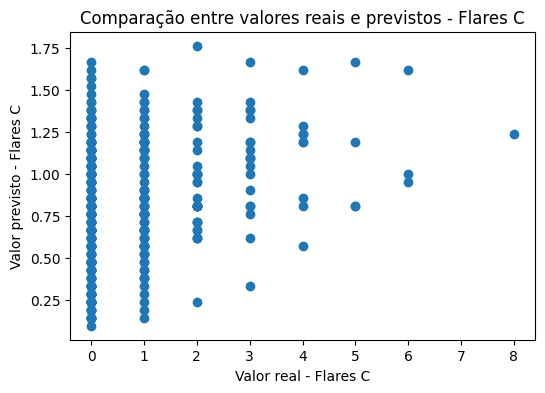

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(y["flares_C_24h"], y_pred_final[:, 0])
plt.xlabel("Valor real - Flares C")
plt.ylabel("Valor previsto - Flares C")
plt.title("Comparação entre valores reais e previstos - Flares C")
plt.show()

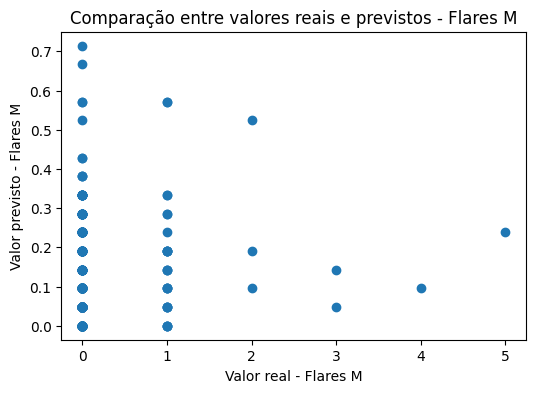

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(y["flares_M_24h"], y_pred_final[:, 1])
plt.xlabel("Valor real - Flares M")
plt.ylabel("Valor previsto - Flares M")
plt.title("Comparação entre valores reais e previstos - Flares M")
plt.show()

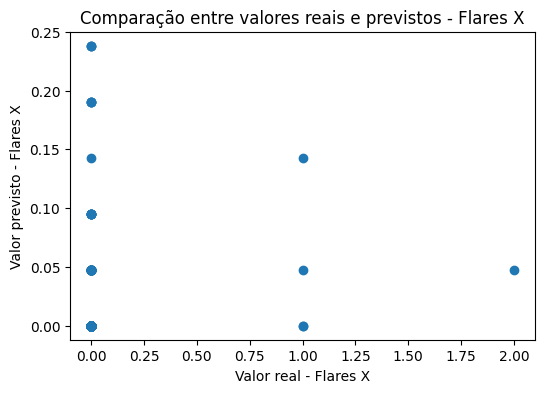

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(y["flares_X_24h"], y_pred_final[:, 2])
plt.xlabel("Valor real - Flares X")
plt.ylabel("Valor previsto - Flares X")
plt.title("Comparação entre valores reais e previstos - Flares X")
plt.show()

In [ ]:
erros = pd.DataFrame({
    "erro_C": y["flares_C_24h"].values - y_pred_final[:, 0],
    "erro_M": y["flares_M_24h"].values - y_pred_final[:, 1],
    "erro_X": y["flares_X_24h"].values - y_pred_final[:, 2],
})

erros.describe()

,erro_C,erro_M,erro_X
count,365.000000,365.000000,365.000000
mean,-0.042140,0.004305,0.003783
std,1.195482,0.504657,0.147759
min,-1.666667,-0.714286,-0.238095
25%,-0.809524,-0.190476,0.000000
50%,-0.380952,-0.047619,0.000000
75%,0.333333,-0.047619,0.000000
max,6.761905,4.761905,1.952381


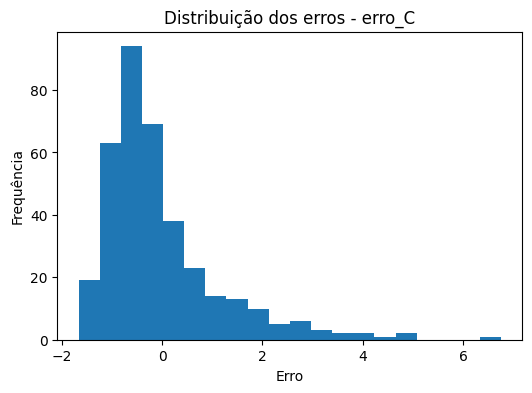

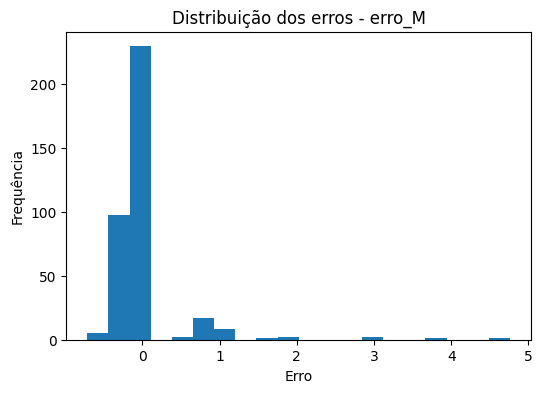

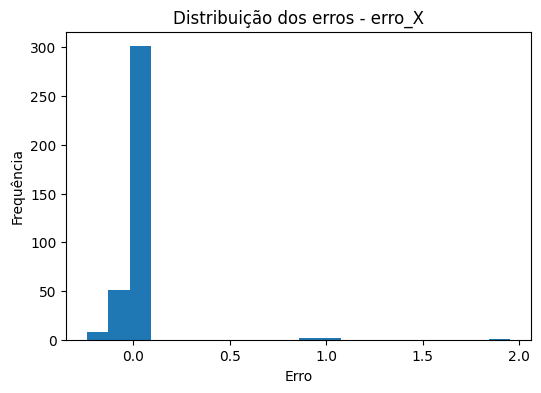

In [ ]:
for coluna in erros.columns:
    plt.figure(figsize=(6, 4))
    plt.hist(erros[coluna], bins=20)
    plt.xlabel("Erro")
    plt.ylabel("Frequência")
    plt.title(f"Distribuição dos erros - {coluna}")
    plt.show()

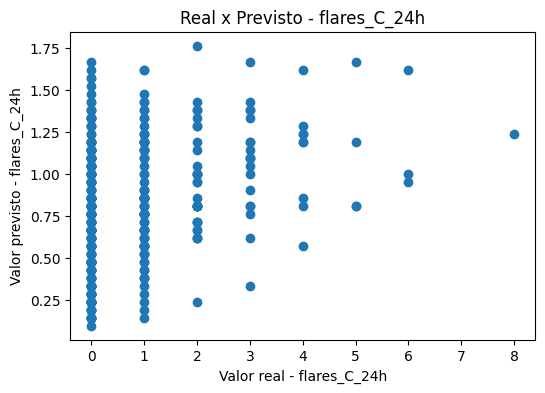

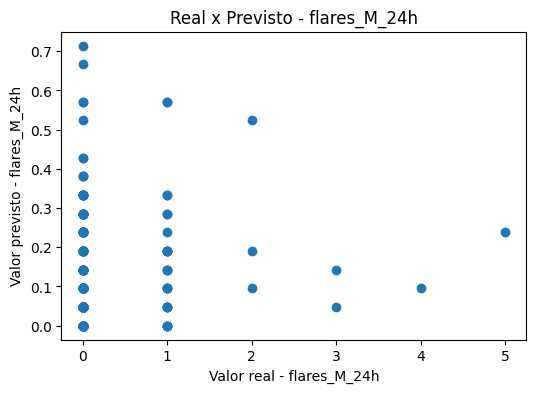

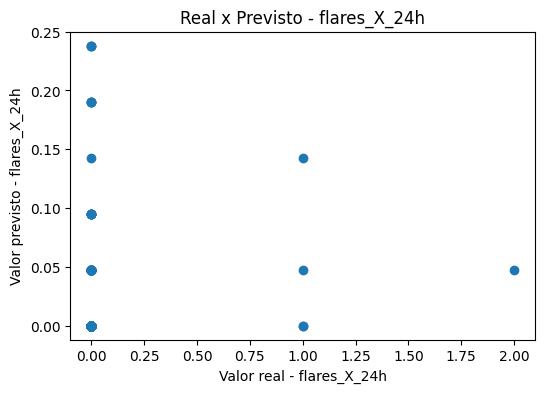

In [ ]:
for i, coluna in enumerate(y.columns):
    plt.figure(figsize=(6, 4))
    plt.scatter(y[coluna], y_pred_final[:, i])
    plt.xlabel(f"Valor real - {coluna}")
    plt.ylabel(f"Valor previsto - {coluna}")
    plt.title(f"Real x Previsto - {coluna}")
    plt.show()

In [ ]:
comparacao_previsto_real = pd.DataFrame({
    "real_C": y["flares_C_24h"].values,
    "previsto_C": y_pred_final[:, 0],
    "real_M": y["flares_M_24h"].values,
    "previsto_M": y_pred_final[:, 1],
    "real_X": y["flares_X_24h"].values,
    "previsto_X": y_pred_final[:, 2],
})

comparacao_previsto_real.head(20)

,real_C,previsto_C,real_M,previsto_M,real_X,previsto_X
0,0,0.238095,0,0.000000,0,0.0
1,0,0.809524,0,0.285714,0,0.0
2,0,0.809524,0,0.142857,0,0.0
3,0,0.285714,0,0.000000,0,0.0
4,0,0.238095,0,0.000000,0,0.0
5,0,0.952381,0,0.000000,0,0.0
6,0,0.380952,0,0.047619,0,0.0
7,0,0.809524,0,0.095238,0,0.0
8,1,0.904762,0,0.000000,0,0.0
9,0,0.571429,0,0.047619,0,0.0


In [ ]:
comparacao_previsto_real = pd.DataFrame({
    "real_C": y["flares_C_24h"].values,
    "previsto_C": y_pred_final[:, 0],
    "real_M": y["flares_M_24h"].values,
    "previsto_M": y_pred_final[:, 1],
    "real_X": y["flares_X_24h"].values,
    "previsto_X": y_pred_final[:, 2],
})

comparacao_previsto_real.head(20)

,real_C,previsto_C,real_M,previsto_M,real_X,previsto_X
0,0,0.238095,0,0.000000,0,0.0
1,0,0.809524,0,0.285714,0,0.0
2,0,0.809524,0,0.142857,0,0.0
3,0,0.285714,0,0.000000,0,0.0
4,0,0.238095,0,0.000000,0,0.0
5,0,0.952381,0,0.000000,0,0.0
6,0,0.380952,0,0.047619,0,0.0
7,0,0.809524,0,0.095238,0,0.0
8,1,0.904762,0,0.000000,0,0.0
9,0,0.571429,0,0.047619,0,0.0


In [ ]:
comparacao_arredondada = comparacao_previsto_real.copy()

colunas_previstas = ["previsto_C", "previsto_M", "previsto_X"]

for coluna in colunas_previstas:
    comparacao_arredondada[coluna] = (
        comparacao_arredondada[coluna]
        .round()
        .clip(lower=0)
        .astype(int)
    )

comparacao_arredondada.head(20)

,real_C,previsto_C,real_M,previsto_M,real_X,previsto_X
0,0,0,0,0,0,0
1,0,1,0,0,0,0
2,0,1,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
5,0,1,0,0,0,0
6,0,0,0,0,0,0
7,0,1,0,0,0,0
8,1,1,0,0,0,0
9,0,1,0,0,0,0


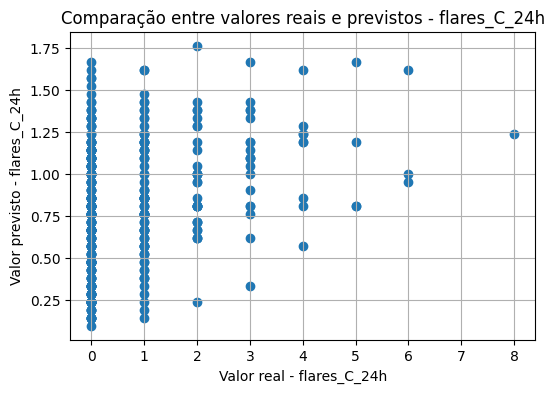

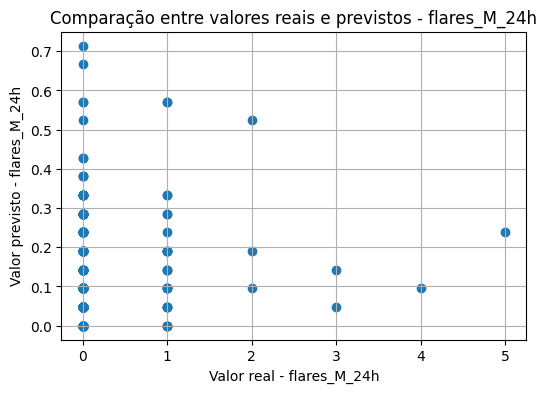

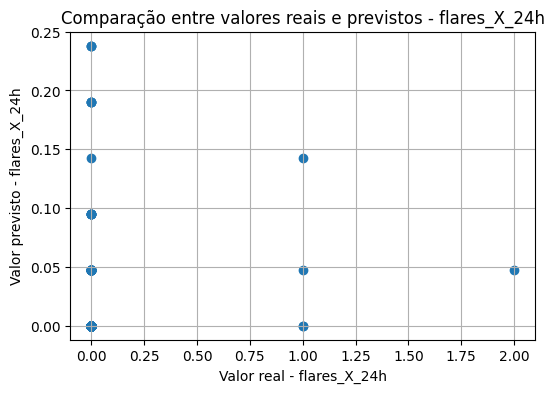

In [ ]:
for i, coluna in enumerate(y.columns):
    plt.figure(figsize=(6, 4))
    plt.scatter(y[coluna], y_pred_final[:, i])
    plt.xlabel(f"Valor real - {coluna}")
    plt.ylabel(f"Valor previsto - {coluna}")
    plt.title(f"Comparação entre valores reais e previstos - {coluna}")
    plt.grid(True)
    plt.show()

In [ ]:
erros = pd.DataFrame({
    "erro_C": y["flares_C_24h"].values - y_pred_final[:, 0],
    "erro_M": y["flares_M_24h"].values - y_pred_final[:, 1],
    "erro_X": y["flares_X_24h"].values - y_pred_final[:, 2],
})

erros.describe()

,erro_C,erro_M,erro_X
count,365.000000,365.000000,365.000000
mean,-0.042140,0.004305,0.003783
std,1.195482,0.504657,0.147759
min,-1.666667,-0.714286,-0.238095
25%,-0.809524,-0.190476,0.000000
50%,-0.380952,-0.047619,0.000000
75%,0.333333,-0.047619,0.000000
max,6.761905,4.761905,1.952381


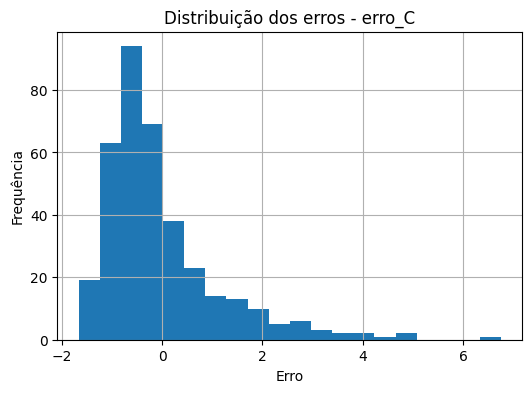

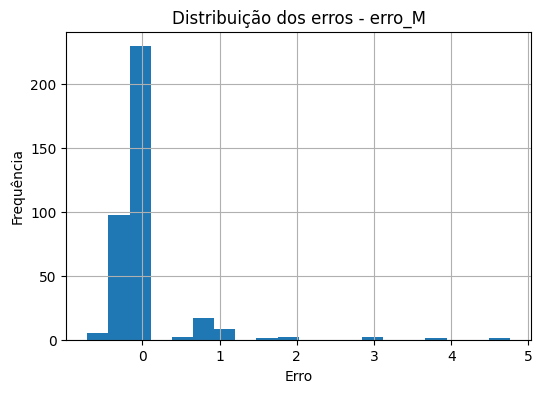

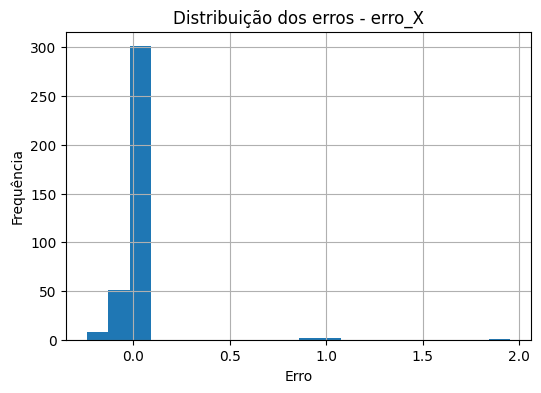

In [ ]:
for coluna in erros.columns:
    plt.figure(figsize=(6, 4))
    plt.hist(erros[coluna], bins=20)
    plt.xlabel("Erro")
    plt.ylabel("Frequência")
    plt.title(f"Distribuição dos erros - {coluna}")
    plt.grid(True)
    plt.show()

In [ ]:
resultado_modelo_final

,modelo,saida,MAE,RMSE,R2
0,Modelo final - KNN otimizado,flares_C_24h,0.8724,1.1946,0.0951
1,Modelo final - KNN otimizado,flares_M_24h,0.2264,0.5040,-0.0111
2,Modelo final - KNN otimizado,flares_X_24h,0.0278,0.1476,-0.0065


In [ ]:
comparacao_arredondada.head(20)

,real_C,previsto_C,real_M,previsto_M,real_X,previsto_X
0,0,0,0,0,0,0
1,0,1,0,0,0,0
2,0,1,0,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,0
5,0,1,0,0,0,0
6,0,0,0,0,0,0
7,0,1,0,0,0,0
8,1,1,0,0,0,0
9,0,1,0,0,0,0


In [ ]:
erros.describe()

,erro_C,erro_M,erro_X
count,365.000000,365.000000,365.000000
mean,-0.042140,0.004305,0.003783
std,1.195482,0.504657,0.147759
min,-1.666667,-0.714286,-0.238095
25%,-0.809524,-0.190476,0.000000
50%,-0.380952,-0.047619,0.000000
75%,0.333333,-0.047619,0.000000
max,6.761905,4.761905,1.952381


# Real x Previsto

# Histogramas dos erros

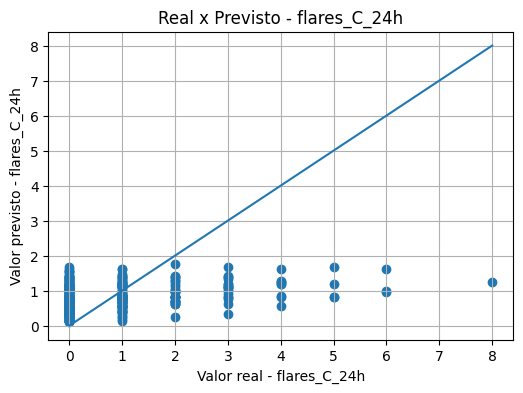

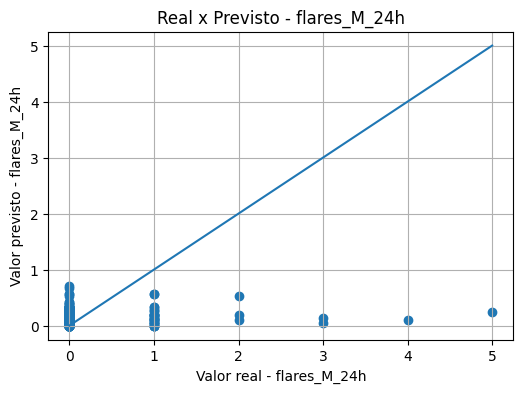

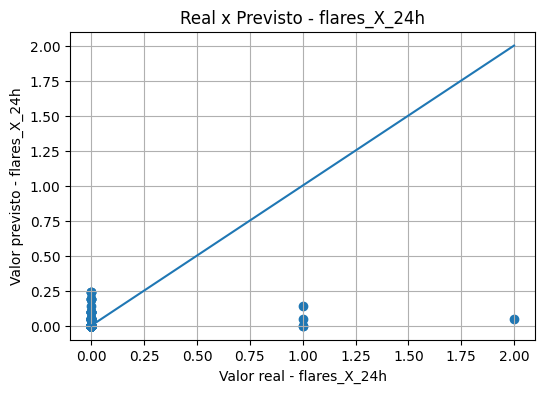

In [ ]:
# Gráficos Real x Previsto

for i, coluna in enumerate(y.columns):
    plt.figure(figsize=(6, 4))
    plt.scatter(y[coluna], y_pred_final[:, i])

    menor = min(y[coluna].min(), y_pred_final[:, i].min())
    maior = max(y[coluna].max(), y_pred_final[:, i].max())
    plt.plot([menor, maior], [menor, maior])

    plt.xlabel(f"Valor real - {coluna}")
    plt.ylabel(f"Valor previsto - {coluna}")
    plt.title(f"Real x Previsto - {coluna}")
    plt.grid(True)
    plt.show()

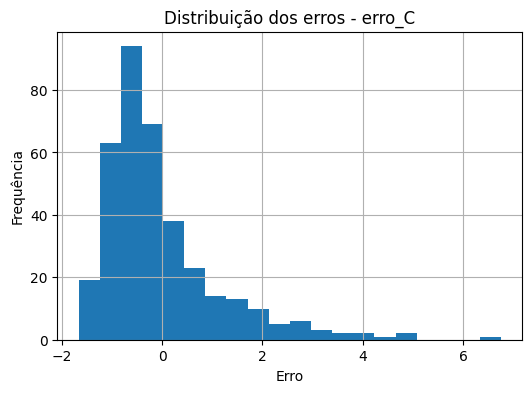

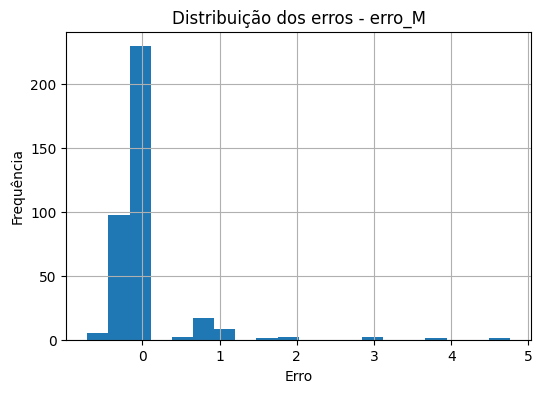

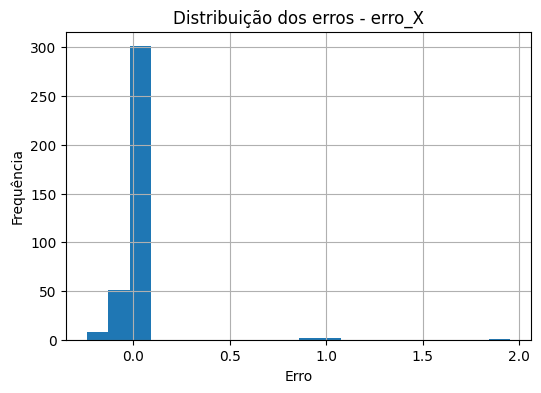

In [ ]:
# Histogramas dos erros

for coluna in erros.columns:
    plt.figure(figsize=(6, 4))
    plt.hist(erros[coluna], bins=20)
    plt.xlabel("Erro")
    plt.ylabel("Frequência")
    plt.title(f"Distribuição dos erros - {coluna}")
    plt.grid(True)
    plt.show()

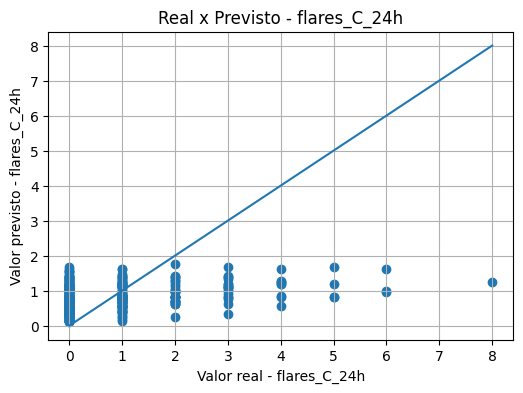

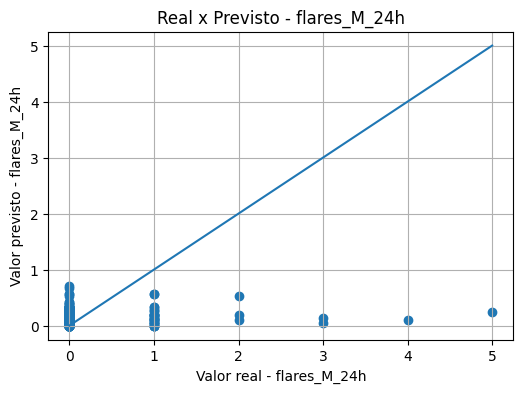

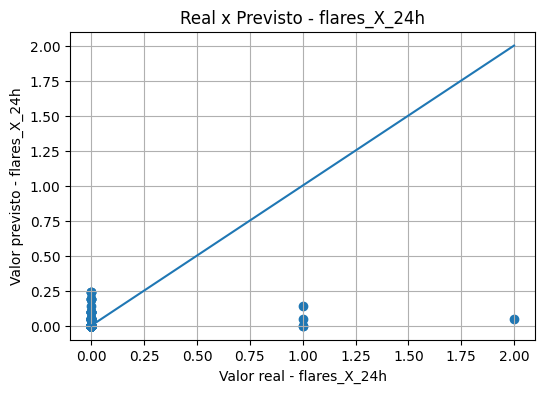

In [ ]:
import os

os.makedirs("graficos", exist_ok=True)

for i, coluna in enumerate(y.columns):
    plt.figure(figsize=(6, 4))
    plt.scatter(y[coluna], y_pred_final[:, i])

    menor = min(y[coluna].min(), y_pred_final[:, i].min())
    maior = max(y[coluna].max(), y_pred_final[:, i].max())
    plt.plot([menor, maior], [menor, maior])

    plt.xlabel(f"Valor real - {coluna}")
    plt.ylabel(f"Valor previsto - {coluna}")
    plt.title(f"Real x Previsto - {coluna}")
    plt.grid(True)
    plt.savefig(f"graficos/real_previsto_{coluna}.png", dpi=300, bbox_inches="tight")
    plt.show()

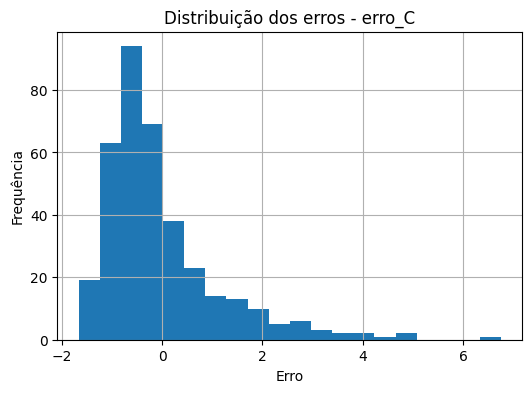

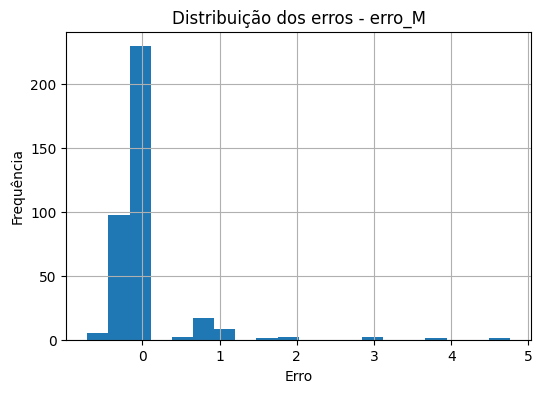

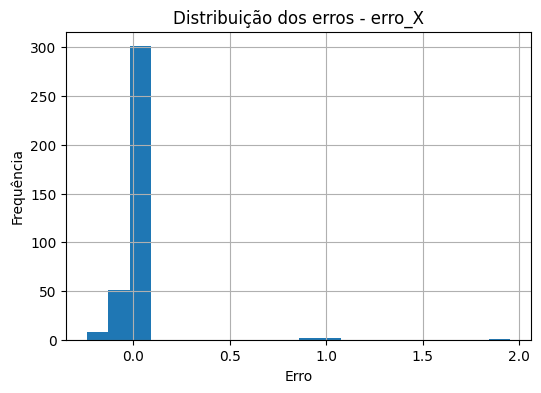

In [ ]:
for coluna in erros.columns:
    plt.figure(figsize=(6, 4))
    plt.hist(erros[coluna], bins=20)
    plt.xlabel("Erro")
    plt.ylabel("Frequência")
    plt.title(f"Distribuição dos erros - {coluna}")
    plt.grid(True)
    plt.savefig(f"graficos/histograma_{coluna}.png", dpi=300, bbox_inches="tight")
    plt.show()